## Set up 

In [1]:
# %% Libraries
import os
import scanpy as sc
#import scvi
import numpy as np
from pathlib import Path
import pandas as pd
import anndata as ad
import rapids_singlecell as rsc


# %% Setting Paths
MAIN_DIR_NAME = "cosmx_gray"
MAIN_DIR = next(p for p in Path.cwd().parents if (p / MAIN_DIR_NAME).exists()) / MAIN_DIR_NAME
os.chdir(MAIN_DIR)

# %% Setting Seed
SEED_VALUE = 42
# set NumPy RNG for consistency
np.random.seed(SEED_VALUE)

# %% object versions
CUR_OBJ_V = 'v8'
CUR_OBJ_PATH = MAIN_DIR / 'data' / 'comb' / 'h5ad' / f'comb_{CUR_OBJ_V}.h5ad'

# %% Load the unintegrated object
comb = sc.read_h5ad(CUR_OBJ_PATH)

/mnt/data/project0062/.conda/envs/rsc_25.12/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# PseudoBulk

aggregate_counts function

In [2]:
import pandas as pd
import numpy as np
from scipy.sparse import issparse

def aggregate_counts(
    adata,
    celltype_col: str,
    samples_col: str,
    celltype_value: str,
    layer: str,
    shape: str = "samples-genes",  # "samples-genes" or "genes-samples"
):
    """
    Filter AnnData to one cell type and return a DataFrame of summed counts.

    Parameters
    ----------
    shape:
      - "samples-genes": rows = samples, columns = genes
      - "genes-samples": rows = genes, columns = samples
    """
    if shape not in {"samples-genes", "genes-samples"}:
        raise ValueError("shape must be one of: 'samples-genes', 'genes-samples'")

    # Filter to chosen cell type
    subset = adata[adata.obs[celltype_col] == celltype_value].copy()

    # Sample labels (one per cell)
    sample_ids = subset.obs[samples_col].astype(str).to_numpy()

    # Extract matrix from layer
    if layer not in subset.layers:
        raise ValueError(f"layer {layer!r} not found in adata.layers")

    X = subset.layers[layer]
    X = X.toarray() if issparse(X) else np.asarray(X)

    # cells × genes dataframe (index = sample id per cell)
    df_cells_genes = pd.DataFrame(X, index=sample_ids, columns=subset.var_names)

    # samples × genes
    df_samples_genes = df_cells_genes.groupby(level=0).sum()

    if shape == "samples-genes":
        return df_samples_genes
    else:  # "genes-samples"
        return df_samples_genes.T


## Generate samples metadata table

In [ ]:
pb_meta = comb.obs[["sample_name", "condition", "run"]].drop_duplicates().set_index("sample_name")
pb_meta

# save the metadata table as csv
meta_path = MAIN_DIR / "results" / "comb" / "ct_de" / "pb_meta.csv"
pb_meta.to_csv(meta_path)

,condition,run
sample_name,,
CTRL01,CTRL,RUN03
PWCF01_1,CF,RUN01
PWCF05,CF,RUN03
PWCF02,CF,RUN02
PWCF03,CF,RUN02
PWCF04,CF,RUN02
CTRL05,CTRL,RUN03
CTRL02,CTRL,RUN03
CTRL03,CTRL,RUN03


## Differential expression (could also try this on R)

Generate metadata

In [4]:
import os
import pickle as pkl

from pydeseq2.dds import DeseqDataSet
from pydeseq2.default_inference import DefaultInference
from pydeseq2.ds import DeseqStats

In [ ]:
celltypes = comb.obs['ann_lvl_3'].unique().tolist()



for ct in celltypes:
    print(f"Processing cell type: {ct}")

    table_dir = MAIN_DIR / 'results' / 'comb' / 'ct_de' / ct

    pb_df = aggregate_counts(
        comb,
        celltype_col='ann_lvl_3',
        samples_col='sample_name',
        celltype_value=ct,
        layer='counts',
        shape='genes-samples',
        #shape='samples-genes'
    )

    # save pseudo-bulk dataframe
    out_dir = table_dir / f'pb_{ct.replace(" ", "_")}.csv'
    pb_df.to_csv(out_dir)


Processing cell type: neutrophils
Processing cell type: macrophages
Processing cell type: cell_debris
Processing cell type: endothelial
Processing cell type: fibroblasts
Processing cell type: T
Processing cell type: AT2
Processing cell type: AT1
Processing cell type: mast
Processing cell type: B
Processing cell type: alveolar_macrophages
Processing cell type: basal
Processing cell type: plasma
Processing cell type: secretory
Processing cell type: smooth_muscle
Processing cell type: ciliated


## PyDESeq2

In [101]:
ANN_LEVEL = 'ann_lvl_3'
CELLTYPE = 'plasma'

pb_df = aggregate_counts(
    comb,
    celltype_col=ANN_LEVEL,
    samples_col='sample_name',
    celltype_value=CELLTYPE,
    layer='counts',
    #shape='genes-samples',
    shape='samples-genes'
)

# filtering 
genes_to_keep = pb_df.columns[pb_df.mean(axis=0) >= 1]
pb_df = pb_df[genes_to_keep]

# filtering ig genes 
if CELLTYPE in ['B','plasma']:
    pb_df = pb_df.copy()
else:
    ig_prefixes = ("IGH", "IGK", "IGL")
    mask_ig = pb_df.columns.to_series().astype(str).str.startswith(ig_prefixes)
    pb_df = pb_df.loc[:, ~mask_ig].copy()

# reorder metadata to match the count table
pb_meta = pb_meta.loc[pb_df.index]

# DESeq2 setup
inference = DefaultInference(n_cpus=32)
dds = DeseqDataSet(
    counts=pb_df,
    metadata=pb_meta,
    design="~run + condition",
    refit_cooks=True,
    inference=inference,
    # n_cpus=8, # n_cpus can be specified here or in the inference object
)

# run DESeq2
dds.deseq2()

# The contrast argument will allow us to determines which variable we want to obtain LFCs and pvalues for. 
# It is a list of three strings of the form ["variable", "tested level", "reference level"]
ds = DeseqStats(dds, contrast=["condition", "CF", "CTRL"], inference=inference)
ds.summary()

de_tbl = ds.results_df
de_tbl



Using None as control genes, passed at DeseqDataSet initialization


Fitting size factors...
... done in 0.00 seconds.

Fitting dispersions...
... done in 0.74 seconds.

Fitting dispersion trend curve...
/mnt/data/project0062/.conda/envs/rapids_singlecell/lib/python3.13/site-packages/pydeseq2/dds.py:820: UserWarning: The dispersion trend curve fitting did not converge. Switching to a mean-based dispersion trend.
  self._fit_parametric_dispersion_trend(vst)
... done in 0.09 seconds.

Fitting MAP dispersions...
... done in 0.70 seconds.

Fitting LFCs...
... done in 0.74 seconds.

Calculating cook's distance...
... done in 0.01 seconds.

Replacing 0 outlier genes.

Running Wald tests...


Log2 fold change & Wald test p-value: condition CF vs CTRL
           baseMean  log2FoldChange     lfcSE      stat    pvalue      padj
A1BG    2122.101643        0.484522  0.406194  1.192834  0.232934  0.630025
A2M      789.855162       -0.866807  0.544619 -1.591586  0.111478  0.487518
AAAS      43.900355        0.587233  0.428681  1.369862  0.170730  0.572034
AAK1      49.545188        0.313941  0.341314  0.919803  0.357676  0.745379
AAMP      84.195783       -0.045115  0.352507 -0.127985  0.898161  0.977834
...             ...             ...       ...       ...       ...       ...
ZSWIM6    18.026584        1.491105  0.751097  1.985237  0.047118  0.346931
ZWINT     24.951227        1.231567  0.626002  1.967353  0.049143  0.352855
ZYG11B    35.206577        0.849513  0.452753  1.876328  0.060610  0.383108
ZYX      122.545436       -0.194384  0.348426 -0.557892  0.576918  0.866149
ZZZ3      39.127956        1.050364  0.400797  2.620688  0.008775  0.158005

[6175 rows x 6 columns]


... done in 0.48 seconds.



,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj
A1BG,2122.101643,0.484522,0.406194,1.192834,0.232934,0.630025
A2M,789.855162,-0.866807,0.544619,-1.591586,0.111478,0.487518
AAAS,43.900355,0.587233,0.428681,1.369862,0.170730,0.572034
AAK1,49.545188,0.313941,0.341314,0.919803,0.357676,0.745379
AAMP,84.195783,-0.045115,0.352507,-0.127985,0.898161,0.977834
...,...,...,...,...,...,...
ZSWIM6,18.026584,1.491105,0.751097,1.985237,0.047118,0.346931
ZWINT,24.951227,1.231567,0.626002,1.967353,0.049143,0.352855
ZYG11B,35.206577,0.849513,0.452753,1.876328,0.060610,0.383108
ZYX,122.545436,-0.194384,0.348426,-0.557892,0.576918,0.866149


In [102]:
# get the number of upregulated and downregulated genes
up_degs= de_tbl[(de_tbl['padj'] < 0.05) & (de_tbl['log2FoldChange'] > 1)]
down_degs = de_tbl[(de_tbl['padj'] < 0.05) & (de_tbl['log2FoldChange'] < -1)]

# number of up and down regulated genes
print(f'upregulated: {len(up_degs)}')
print(f'downregulated: {len(down_degs)}')

upregulated: 56
downregulated: 62


In [103]:
print(up_degs.index)
print(down_degs.index)

Index(['AGRP', 'AQP7', 'B9D2', 'BASP1', 'BMP6', 'BTG2', 'CASP10', 'CCDC50',
       'CD79A', 'CDK17', 'CDK5RAP3', 'CHMP3', 'COBLL1', 'COL9A3', 'CPEB4',
       'CREB3L2', 'CSNK1E', 'CXCL14', 'CYBA', 'DUSP2', 'EPB41L5', 'ESR2',
       'FCRL5', 'GCDH', 'GIGYF2', 'H2AX', 'H2BC5', 'HAND1', 'HECTD1', 'IGFBP5',
       'IGHG1/2', 'IGLL1', 'ITGA6', 'MEF2D', 'NPFF', 'OGT', 'OSBPL3', 'PABPN1',
       'PDCD4', 'PHC3', 'PHKA1', 'PLCG2', 'POU2AF1', 'PTK2', 'PTK2B', 'RGS5',
       'RRBP1', 'SEC31A', 'SFRP2', 'SFRP4', 'SLC25A17', 'STAT2', 'TARDBP',
       'TPD52', 'UBE2D4', 'XBP1'],
      dtype='object')
Index(['ACVR2A', 'ADRA1B', 'B3GALNT1', 'BATF3', 'BCL11A', 'BOK', 'BRF2',
       'C9orf72', 'CACNA1I', 'CALML3', 'CCL20', 'CCL21', 'CDK5RAP2', 'CDK7',
       'CLDN5', 'CLU', 'COX1', 'COX2', 'CT45A', 'CTAGE1', 'CTNNAL1', 'CTSL',
       'DLL4', 'DYNC1I1', 'ETS2', 'FZD8', 'G0S2', 'G6PC2', 'GPX3', 'HGSNAT',
       'HMGA2', 'HSPA1B', 'ICOS', 'IFIT2', 'IGHD', 'IL18R1', 'KRT14', 'LIPA',
       'LYVE1', 'MED19'

In [1]:
de_tbl.loc[['S100A8', 'S100A9']]

NameError: name 'de_tbl' is not defined

upregulated

In [37]:
de_tbl.sort_values('log2FoldChange', ascending = False).head(20).index

Index(['MSMB', 'TFF3', 'SAA1', 'CD24', 'MUC4', 'HLA-DRA', 'C3', 'HLA-DPA1',
       'CXCL6', 'LCN2', 'NFASC', 'DUSP2', 'AGRP', 'IFI27', 'MHC I', 'GRM7',
       'IL22RA2', 'CXCL1', 'CCN2', 'CD74'],
      dtype='object')

downregulated

In [38]:
de_tbl.sort_values('log2FoldChange', ascending = True).head(20).index

Index(['SCGB3A1', 'SCGB1A1', 'COX1', 'MGP', 'ICAM1', 'DAPK1', 'COX2', 'ADGRF5',
       'EFNB2', 'STMN1', 'IGF2', 'RNASE1', 'LGALS1', 'EFNA4', 'ADIRF',
       'CYP4B1', 'TM4SF1', 'KRT4', 'TRIB3', 'GZMB'],
      dtype='object')

volcano plot function 

In [25]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def volcano_plot(
    df: pd.DataFrame,
    lfc_col: str = "log2FoldChange",
    p_col: str = "padj",              # use "pvalue" if you prefer
    gene_col: str | None = None,      # if None, uses df.index
    lfc_thresh: float = 1.0,
    p_thresh: float = 0.05,
    label_top: int = 15,              # 0 = no labels
    label_by: str = "p",              # "p" or "abs_lfc"
    figsize=(30,15),
    ax=None,
    title: str | None = None,
    alpha: float = 0.7,
    s: float = 14,
):
    """
    Make a volcano plot from a DESeq2-like results table.

    df: DataFrame with columns like log2FoldChange + padj/pvalue.
        Gene names can be in df.index or in a column (gene_col).
    """
    if lfc_col not in df.columns or p_col not in df.columns:
        raise ValueError(f"df must contain columns: {lfc_col!r} and {p_col!r}")

    d = df.copy()

    # gene names
    if gene_col is None:
        if d.index is None:
            raise ValueError("No index found. Provide gene_col.")
        d["__gene__"] = d.index.astype(str)
    else:
        if gene_col not in d.columns:
            raise ValueError(f"gene_col {gene_col!r} not in df.columns")
        d["__gene__"] = d[gene_col].astype(str)

    # numeric
    d["__lfc__"] = pd.to_numeric(d[lfc_col], errors="coerce")
    d["__p__"]   = pd.to_numeric(d[p_col], errors="coerce")

    # keep finite values
    d = d.replace([np.inf, -np.inf], np.nan).dropna(subset=["__lfc__", "__p__"])
    d = d[d["__p__"] > 0].copy()
    if d.empty:
        raise ValueError("No valid rows after filtering (need finite LFC and p > 0).")

    # -log10(p)
    d["__neglog10p__"] = -np.log10(d["__p__"].values)

    # classify points
    sig = d["__p__"] < p_thresh
    up = sig & (d["__lfc__"] >= lfc_thresh)
    down = sig & (d["__lfc__"] <= -lfc_thresh)
    d["__status__"] = "NS"
    d.loc[up, "__status__"] = "Up"
    d.loc[down, "__status__"] = "Down"

    # setup plot
    if ax is None:
        fig, ax = plt.subplots(figsize=figsize)
    else:
        fig = ax.figure

    # (you can change these if you want)
    color_map = {"Down": "tab:blue", "NS": "0.7", "Up": "tab:red"}

    for status in ["Down", "NS", "Up"]:
        sub = d[d["__status__"] == status]
        ax.scatter(sub["__lfc__"], sub["__neglog10p__"], s=s, alpha=alpha,
                   c=color_map[status], label=status)

    # threshold lines
    ax.axvline(-lfc_thresh, linestyle="--", linewidth=1)
    ax.axvline(lfc_thresh, linestyle="--", linewidth=1)
    ax.axhline(-np.log10(p_thresh), linestyle="--", linewidth=1)

    ax.set_xlabel("log2 fold change")
    ax.set_ylabel(r"$-\log_{10}$(p-value)")
    ax.set_title(title or "Volcano plot")
    ax.legend(frameon=False)

    # labels (top significant hits)
    if label_top and label_top > 0:
        sig_df = d[d["__status__"] != "NS"].copy()
        if not sig_df.empty:
            if label_by == "abs_lfc":
                sig_df["__score__"] = -sig_df["__lfc__"].abs()
            else:  # default: smallest p first
                sig_df["__score__"] = sig_df["__p__"]

            lab = sig_df.sort_values("__score__").head(label_top)

            texts = []
            for _, r in lab.iterrows():
                texts.append(ax.text(r["__lfc__"], r["__neglog10p__"], r["__gene__"], fontsize=9))

            # optional: nicer label placement if adjustText is installed
            try:
                from adjustText import adjust_text
                adjust_text(texts, ax=ax, arrowprops=dict(arrowstyle="-", lw=0.5))
            except Exception:
                pass

    return fig, ax


# Example:
# fig, ax = volcano_plot(res_df, p_col="padj", lfc_thresh=1, p_thresh=0.05, label_top=20)
# plt.show()


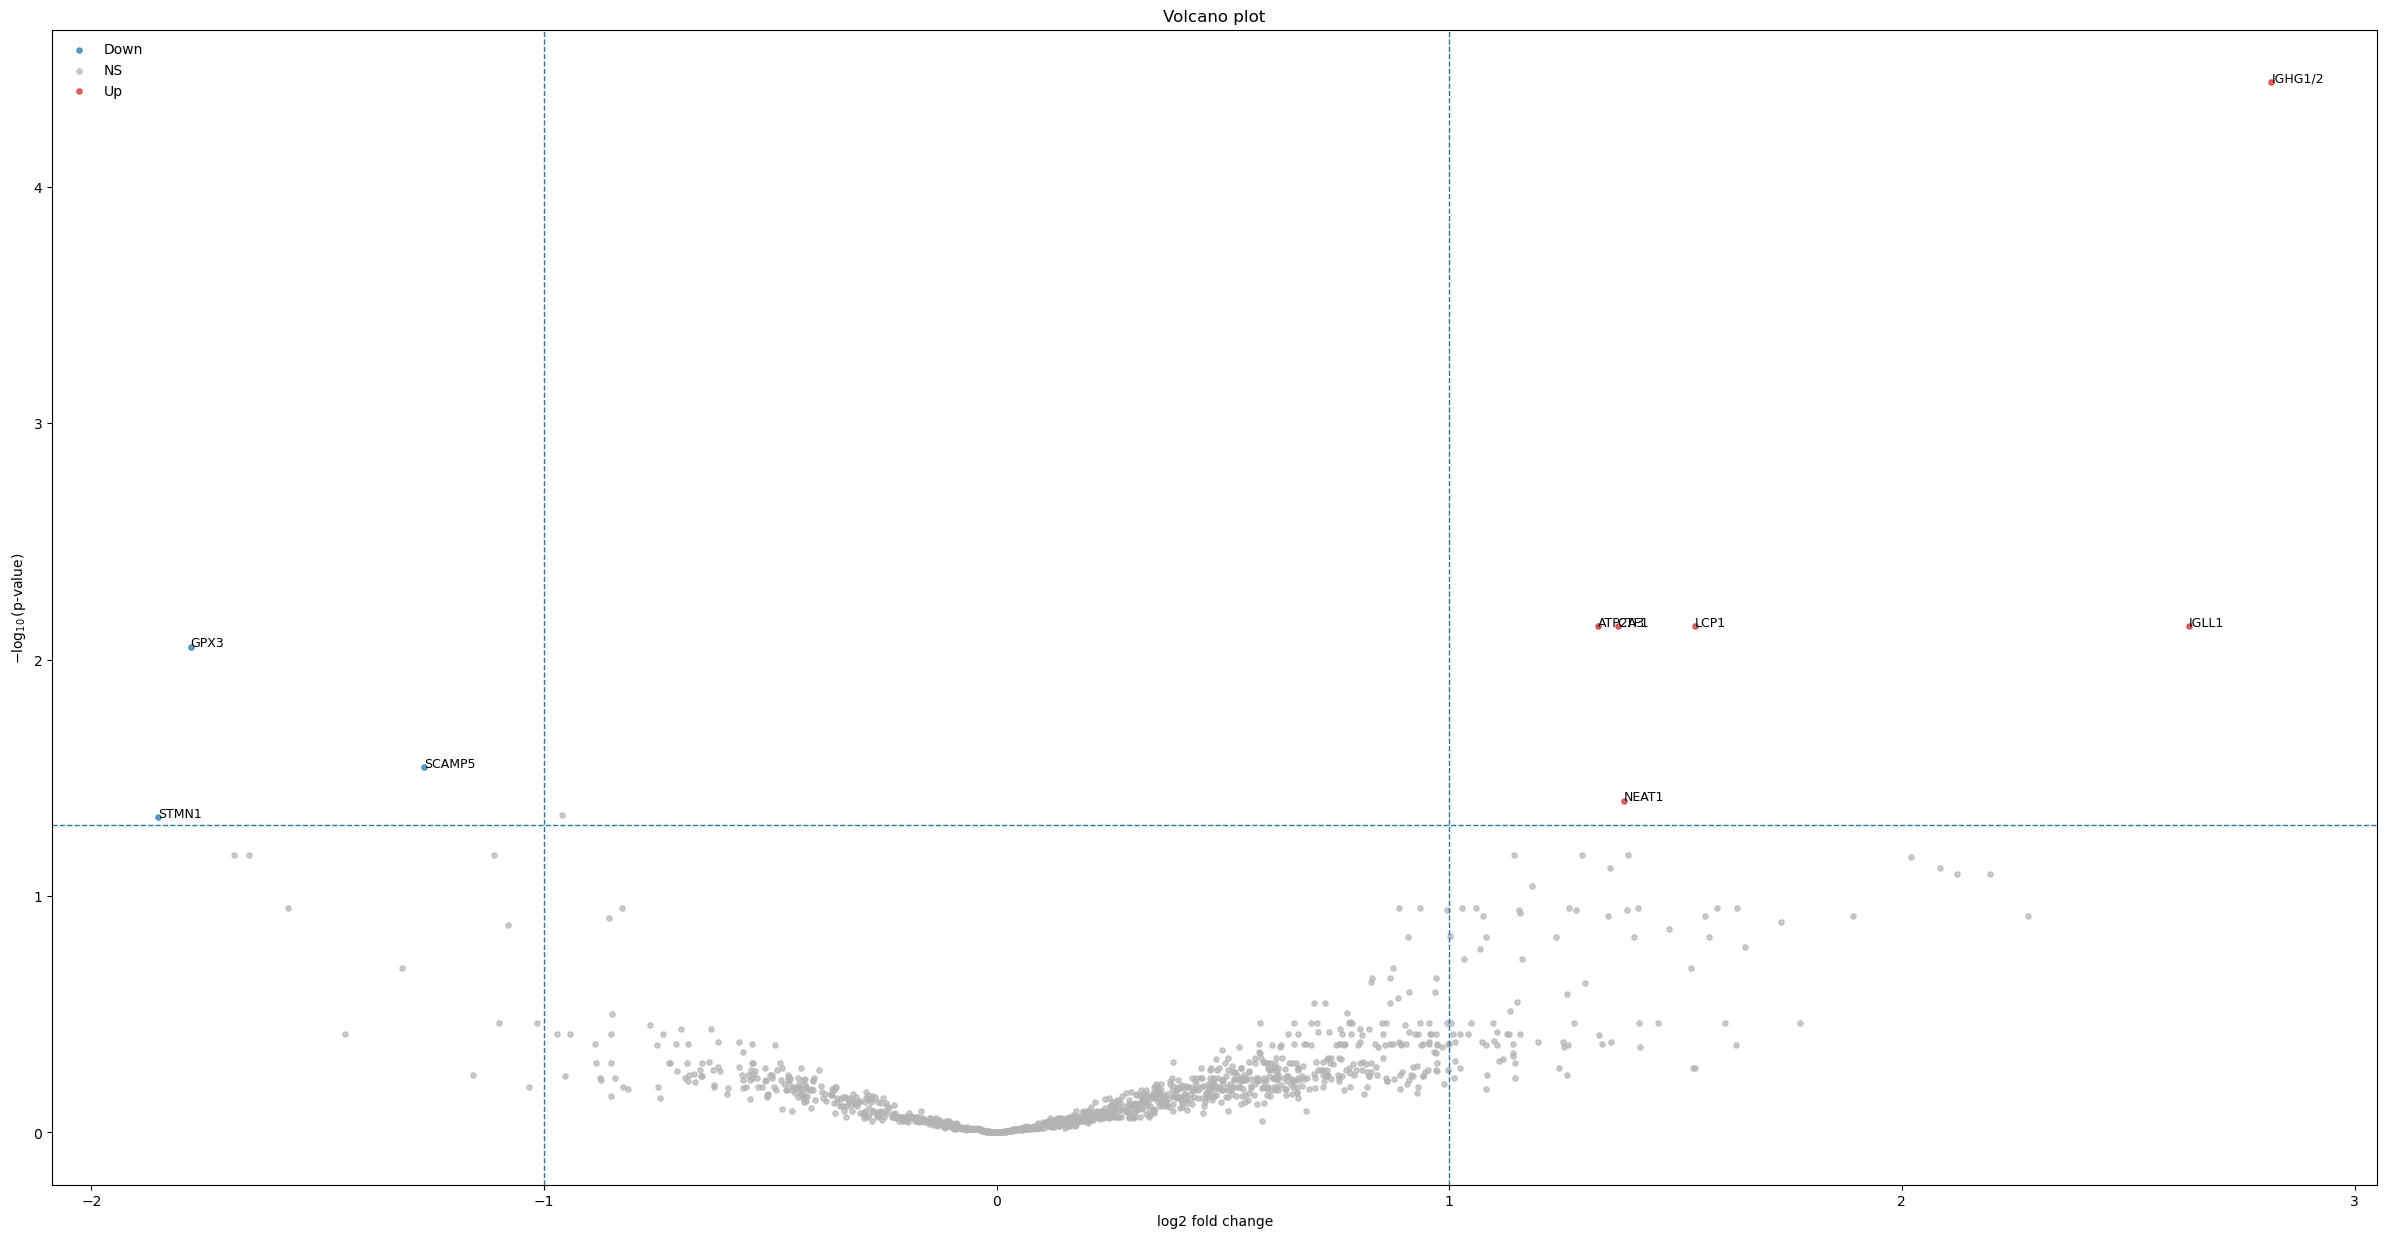

In [49]:
fig, ax = volcano_plot(de_tbl, p_col="padj", lfc_thresh=1, p_thresh=0.05, label_top=20)
plt.show()

In [61]:
comb.obs['ann_lvl_3'].value_counts()


ann_lvl_3
endothelial             182554
plasma                  151055
macrophages             136521
fibroblasts             129566
T                       109251
AT2                      95247
ciliated                 93451
secretory                75733
basal                    66518
neutrophils              60003
cell_debris              59945
smooth_muscle            53576
B                        48835
mast                     25083
AT1                      24297
alveolar_macrophages     15151
Name: count, dtype: int64

In [ ]:
# get the number of upregulated and downregulated genes
up_degs= de_tbl[(de_tbl['padj'] < 0.05) & (de_tbl['log2FoldChange'] > 1)]
down_degs = de_tbl[(de_tbl['padj'] < 0.05) & (de_tbl['log2FoldChange'] < -1)]

# number of up and down regulated genes
print(f'upregulated: {len(up_degs)}')
print(f'downregulated: {len(down_degs)}')


upregulated: 88
downregulated: 120
